In [1]:
import geopandas as gpd
import pandas as pd

**Raw Data Inspection**

In [3]:
# 1. Load the raw Shapefile
# Note: Path is based on your file explorer: ../data/taxi_zones/taxi_zones.shp
zones_raw = gpd.read_file('../data/taxi_zones/taxi_zones.shp')

# 2. Check the raw count and structure
print(f"Total rows in raw shapefile: {len(zones_raw)}")
print("\n--- Raw Column Names ---")
print(zones_raw.columns.tolist())

# 3. Inspect the unique LocationIDs to see what we are dealing with
print(f"\nMin LocationID: {zones_raw['LocationID'].min()}")
print(f"Max LocationID: {zones_raw['LocationID'].max()}")

# 4 Check for missing or invalid geometries
null_geo = zones_raw.geometry.isna().sum()
invalid_geo = (~zones_raw.geometry.is_valid).sum()
print(f"\nMissing geometries: {null_geo}")
print(f"Invalid geometries: {invalid_geo}")

Total rows in raw shapefile: 263

--- Raw Column Names ---
['OBJECTID', 'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough', 'geometry']

Min LocationID: 1
Max LocationID: 263

Missing geometries: 0
Invalid geometries: 0


**Centroid Computation**

In [4]:
# 1. Project to NYC State Plane (EPSG:2263) for accurate math in feet
zones_gdf = zones_raw.to_crs(epsg=2263)

# 2. Compute Centroids (Methodology Step 4)
# This creates a 'Point' for every zone polygon
zones_gdf['centroid'] = zones_gdf.geometry.centroid

# 3. Validation for your report: Check the CRS and the first few centroids
print(f"Current CRS: {zones_gdf.crs}")
print("\n--- Zone Centroids Calculated ---")
print(zones_gdf[['LocationID', 'zone', 'centroid']].head())

Current CRS: EPSG:2263

--- Zone Centroids Calculated ---
   LocationID                     zone                        centroid
0           1           Newark Airport    POINT (935996.821 191376.75)
1           2              Jamaica Bay  POINT (1031085.719 164018.754)
2           3  Allerton/Pelham Gardens  POINT (1026452.617 254265.479)
3           4            Alphabet City   POINT (990633.981 202959.782)
4           5            Arden Heights    POINT (931871.37 140681.351)


Validating Coordinates Centroids

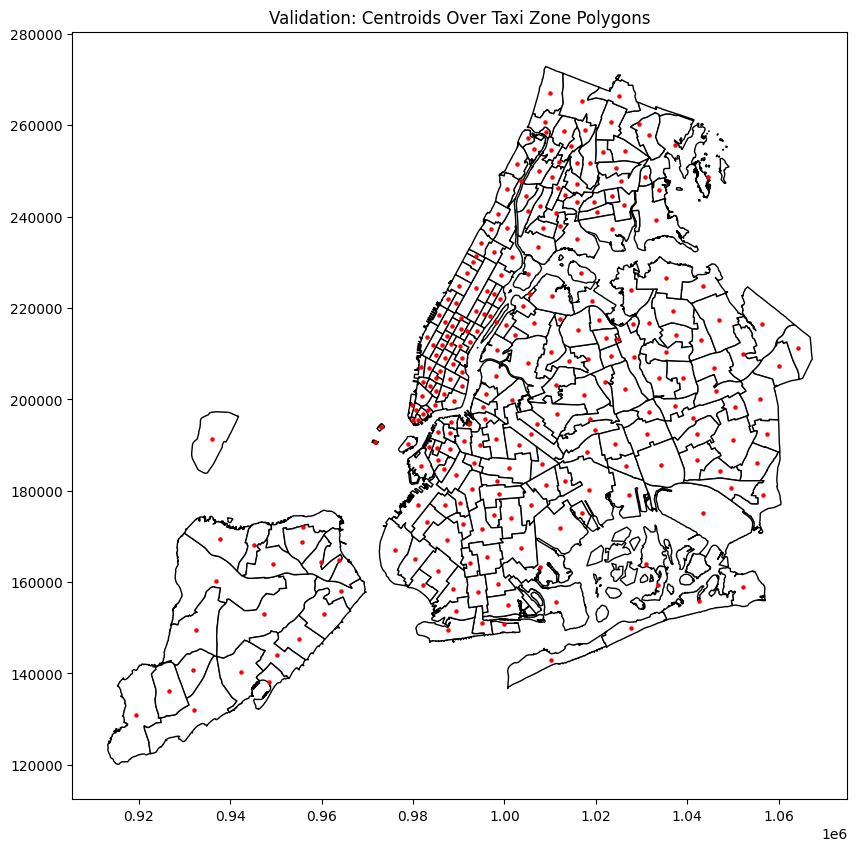

In [5]:
import matplotlib.pyplot as plt

# Create the plot
base = zones_gdf.plot(color='white', edgecolor='black', figsize=(10, 10))
zones_gdf['centroid'].plot(ax=base, marker='o', color='red', markersize=5)

plt.title("Validation: Centroids Over Taxi Zone Polygons")
plt.show()

Spacial Join

In [ ]:
# 1. Load your padded Dataset 1 (from the parquet file we saved)
df_taxi = pd.read_parquet('../data/processed/taxi_demand_hourly_padded.parquet', engine='fastparquet')

# 2. Merge with your validated zones_gdf
# We keep the names, boroughs, and centroids for future distance math
df_combined = pd.merge(
    df_taxi, 
    zones_gdf[['LocationID', 'zone', 'borough', 'centroid']], 
    left_on='PULocationID', 
    right_on='LocationID', 
    how='left'
)

# 3. Clean up the redundant key
df_combined = df_combined.drop(columns=['LocationID'])

# 4. Final Validation for your report
print(f"Combined Dataset Shape: {df_combined.shape}")
print(f"Memory Usage: {df_combined.memory_usage().sum() / 1024**2:.2f} MB")
print("\n--- Sample of the Integrated Dataset ---")
print(df_combined.head())


Combined Dataset Shape: (568080, 10)
Memory Usage: 36.84 MB

--- Sample of the Integrated Dataset ---
   PULocationID tpep_pickup_datetime        date  hour  day_of_week  month  \
0             1  2025-01-01 00:00:00  2025-01-01     0            2      1   
1             1  2025-01-01 01:00:00  2025-01-01     1            2      1   
2             1  2025-01-01 02:00:00  2025-01-01     2            2      1   
3             1  2025-01-01 03:00:00  2025-01-01     3            2      1   
4             1  2025-01-01 04:00:00  2025-01-01     4            2      1   

   pickup_count            zone borough                      centroid  
0             0  Newark Airport     EWR  POINT (935996.821 191376.75)  
1             0  Newark Airport     EWR  POINT (935996.821 191376.75)  
2             0  Newark Airport     EWR  POINT (935996.821 191376.75)  
3             0  Newark Airport     EWR  POINT (935996.821 191376.75)  
4             0  Newark Airport     EWR  POINT (935996.821 191376.75)

In [11]:
print(df_combined.dtypes)

PULocationID                     int64
tpep_pickup_datetime    datetime64[ns]
date                            object
hour                             int32
day_of_week                      int32
month                            int32
pickup_count                     int64
zone                            object
borough                         object
centroid                      geometry
dtype: object


Exporting taxi Spacial Data

In [13]:
# 1. Convert 'date' to string for Parquet compatibility
df_combined['date'] = df_combined['date'].astype(str)

# 2. Corrected way to extract X and Y from the centroid points
# We use .apply(lambda p: p.x) to visit each individual point
df_combined['centroid_x'] = df_combined['centroid'].apply(lambda p: p.x)
df_combined['centroid_y'] = df_combined['centroid'].apply(lambda p: p.y)

# 3. Drop the objects to keep the file clean and ML-ready
# We drop 'centroid' (the object) and the raw timestamp
df_backbone = df_combined.drop(columns=['centroid', 'tpep_pickup_datetime'])

# 4. Save using fastparquet
df_backbone.to_parquet(
    '../data/processed/taxi_spatial_backbone.parquet', 
    index=False, 
    engine='fastparquet'
)

print("Backbone exported successfully! You now have a clean file with centroid_x and centroid_y columns.")

Backbone exported successfully! You now have a clean file with centroid_x and centroid_y columns.
